# Clase 09 - Exploratory Data Analysis


Dataset: https://data.cityofchicago.org/Public-Safety/Crime… 

Objetivos del analisis:
1. Hay estacionalidad en los crimenes? 
2. Que lugares de Chicago son mas peligrosos? 
3. Que tipo de crimenes son los mas frecuentes?

In [10]:
import random
import pandas as pd
from urllib.parse import urlencode

# Dataset: Crimes - 2001 to Present (data.cityofchicago.org, id ijzp-q8t2)
url = "https://data.cityofchicago.org/resource/ijzp-q8t2.json"
YEAR_MIN = 2001
YEAR_MAX = 2024
N_TOTAL = 500_000

# La API no ofrece un "sample" nativo, asi que para no bajar los ~8 millones
# de filas completas armamos un muestreo por anio: para cada anio pedimos su
# cantidad total de crimenes y despues traemos un bloque de tamanio
# proporcional arrancando desde un offset aleatorio.
n_years = YEAR_MAX - YEAR_MIN + 1
n_por_anio = N_TOTAL // n_years

muestras = []
for year in range(YEAR_MIN, YEAR_MAX + 1):
    count_params = {"$select": "count(*) as total", "$where": f"year = {year}"}
    total_anio = int(pd.read_json(url + "?" + urlencode(count_params))["total"][0])

    n = min(n_por_anio, total_anio)
    offset_max = max(total_anio - n, 0)
    offset = random.randint(0, offset_max)

    params = {
        "$limit": n,
        "$offset": offset,
        "$where": f"year = {year}",
        "$order": "date",
    }
    pagina = pd.read_json(url + "?" + urlencode(params))
    muestras.append(pagina)
    print(f"{year}: {len(pagina)} filas muestreadas (de {total_anio} totales)")

df = pd.concat(muestras, ignore_index=True)
df.shape

2001: 20833 filas muestreadas (de 485977 totales)
2002: 20833 filas muestreadas (de 486843 totales)
2003: 20833 filas muestreadas (de 476013 totales)
2004: 20833 filas muestreadas (de 469447 totales)
2005: 20833 filas muestreadas (de 453803 totales)
2006: 20833 filas muestreadas (de 448211 totales)
2007: 20833 filas muestreadas (de 437117 totales)
2008: 20833 filas muestreadas (de 427231 totales)
2009: 20833 filas muestreadas (de 392877 totales)
2010: 20833 filas muestreadas (de 370588 totales)
2011: 20833 filas muestreadas (de 352083 totales)
2012: 20833 filas muestreadas (de 336406 totales)
2013: 20833 filas muestreadas (de 307646 totales)
2014: 20833 filas muestreadas (de 275913 totales)
2015: 20833 filas muestreadas (de 264945 totales)
2016: 20833 filas muestreadas (de 270032 totales)
2017: 20833 filas muestreadas (de 269349 totales)
2018: 20833 filas muestreadas (de 269239 totales)
2019: 20833 filas muestreadas (de 261938 totales)
2020: 20833 filas muestreadas (de 213071 totales)


(499992, 22)

In [ ]:
df.head()

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,year,updated_on,x_coordinate,y_coordinate,latitude,longitude,location
0,14339976,JK428312,2026-09-26,015XX N LEAVITT ST,0610,BURGLARY,FORCIBLE ENTRY,RESIDENCE - GARAGE,False,False,...,1,24,05,2026,2026-09-28T15:56:02.000,NaN,NaN,NaN,NaN,NaN
1,14334622,JK421979,2026-09-21,008XX N PAULINA ST,0560,ASSAULT,SIMPLE,APARTMENT,False,False,...,1,24,08A,2026,2026-09-28T16:01:21.000,1164899.0,1906055.0,41.897822,-87.669787,"{'latitude': '41.897822462', 'longitude': '-87..."
2,14335196,JK422463,2026-09-21,043XX S ST LOUIS AVE,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,STREET,False,False,...,12,58,07,2026,2026-09-28T16:01:21.000,1153790.0,1875705.0,41.814767,-87.711397,"{'latitude': '41.814767094', 'longitude': '-87..."
3,14335006,JK422252,2026-09-21,046XX N SHERIDAN RD,0760,BURGLARY,BURGLARY FROM MOTOR VEHICLE,STREET,False,False,...,46,3,06,2026,2026-09-28T16:01:21.000,1168782.0,1931169.0,41.966653,-87.654795,"{'latitude': '41.966653193', 'longitude': '-87..."
4,14334918,JK422115,2026-09-21,042XX N ELSTON AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,True,False,...,39,16,14,2026,2026-09-28T16:01:21.000,1149764.0,1927716.0,41.957570,-87.724812,"{'latitude': '41.957569913', 'longitude': '-87..."


In [3]:
df.groupby(df["date"].dt.to_period("M")).size()

date
2026-07    16235
2026-08    20723
2026-09    13042
Freq: M, dtype: int64

## 1. Hay estacionalidad en los crimenes?

Para responder esto convertimos la columna `date` a tipo datetime y agregamos los crimenes por mes (y por dia de la semana) para ver si hay patrones que se repiten a lo largo del tiempo.

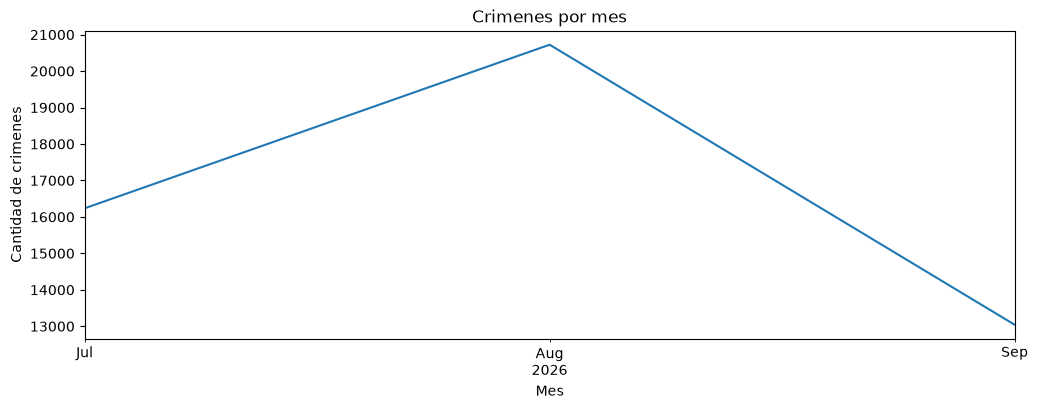

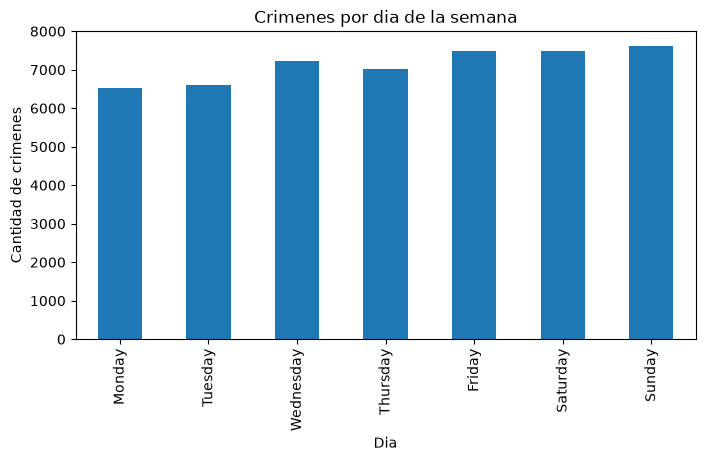

In [4]:
import matplotlib.pyplot as plt

df["date"] = pd.to_datetime(df["date"])

# Crimenes por mes
crimenes_por_mes = df.groupby(df["date"].dt.to_period("M")).size()
crimenes_por_mes.plot(kind="line", figsize=(12, 4), title="Crimenes por mes")
plt.ylabel("Cantidad de crimenes")
plt.xlabel("Mes")
plt.show()

# Crimenes por dia de la semana
crimenes_por_dia = df.groupby(df["date"].dt.day_name()).size()
orden_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
crimenes_por_dia = crimenes_por_dia.reindex(orden_dias)
crimenes_por_dia.plot(kind="bar", figsize=(8, 4), title="Crimenes por dia de la semana")
plt.ylabel("Cantidad de crimenes")
plt.xlabel("Dia")
plt.show()

## 2. Que lugares de Chicago son mas peligrosos?

Uso las columnas `community_area` (area comunitaria) y `district` (distrito policial) que trae el dataset, cuento la cantidad de crimenes por cada una y me quedo con las que mas casos acumulan. Tambien hago el gráfico de la ubicacion de los crimenes (`latitude`/`longitude`) para ver como se distribuyen geograficamente.

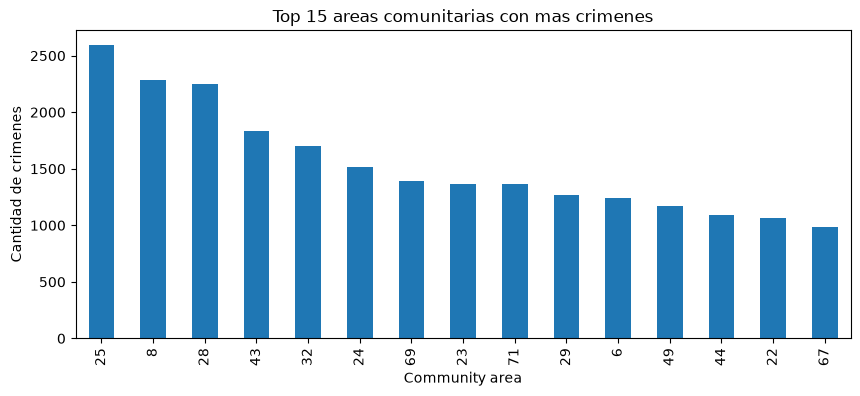

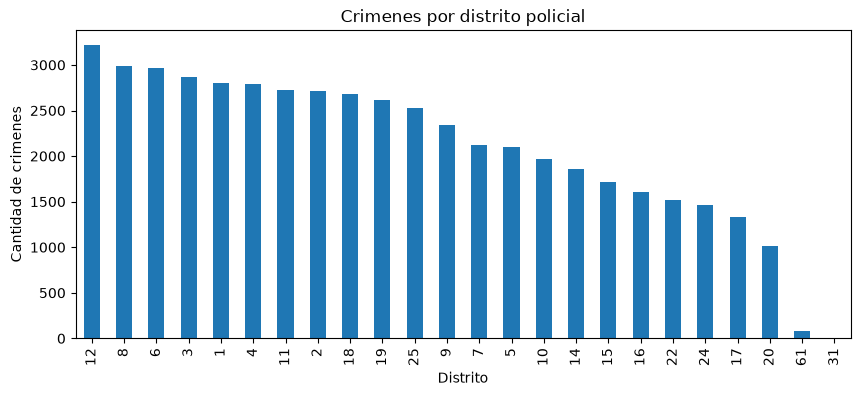

In [5]:
# Top 15 areas comunitarias con mas crimenes
crimenes_por_area = df.groupby("community_area").size().sort_values(ascending=False)
crimenes_por_area.head(15).plot(kind="bar", figsize=(10, 4), title="Top 15 areas comunitarias con mas crimenes")
plt.ylabel("Cantidad de crimenes")
plt.xlabel("Community area")
plt.show()

# Crimenes por distrito policial
crimenes_por_distrito = df.groupby("district").size().sort_values(ascending=False)
crimenes_por_distrito.plot(kind="bar", figsize=(10, 4), title="Crimenes por distrito policial")
plt.ylabel("Cantidad de crimenes")
plt.xlabel("Distrito")
plt.show()

In [18]:
%pip install -q folium

Note: you may need to restart the kernel to use updated packages.


In [8]:
# Distribucion geografica de los crimenes sobre el mapa real de Chicago
import folium
from folium.plugins import HeatMap

# Los ultimos crimenes cargados en `df` suelen no tener todavia latitude/longitude
# (la geocodificacion tarda unos dias), asi que para el mapa pedimos una muestra
# de crimenes que ya tengan ubicacion cargada.
params_geo = {"$limit": 20000, "$where": "latitude IS NOT NULL"}
df_geo = pd.read_json(url + "?" + urlencode(params_geo))
df_geo = df_geo.dropna(subset=["latitude", "longitude"])
print(df_geo.shape)

mapa_chicago = folium.Map(location=[41.8781, -87.6298], zoom_start=11, tiles="OpenStreetMap")
HeatMap(df_geo[["latitude", "longitude"]].values.tolist(), radius=8, blur=6).add_to(mapa_chicago)
mapa_chicago

(20000, 22)
